In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE

In [61]:
DATASET_DIR = os.path.join(os.path.dirname(os.getcwd()), 'datasets')

# 1. Load the FineSat feature matrix and labels
X_fs = np.load(os.path.join(DATASET_DIR, "X_finesat_c3.2.npy"))
Y_fs = np.load(os.path.join(DATASET_DIR, "Y_finesat_c3.2.npy"))

In [62]:
# Health check for number of samples
X_fs.shape, Y_fs.shape

((226, 78), (226,))

In [63]:
# Encoding labels
label_encoder_fs = LabelEncoder()
Y_encoded_fs = label_encoder_fs.fit_transform(Y_fs)

In [64]:
# train-test split: 80-20 ratio
X_train_fs, X_test_fs, Y_train_fs, Y_test_fs = train_test_split(
    X_fs, Y_encoded_fs, test_size=0.2, random_state=42, stratify=Y_encoded_fs
)

In [69]:
# Scale features (Mean=0, Variance=1)
scaler_fs = StandardScaler()
X_train_scaled_fs = scaler_fs.fit_transform(X_train_fs)
X_test_scaled_fs = scaler_fs.transform(X_test_fs)

In [70]:
tsne_fs = TSNE(n_components=2, random_state=42)
X_embedded_fs = tsne_fs.fit_transform(X_train_scaled_fs)

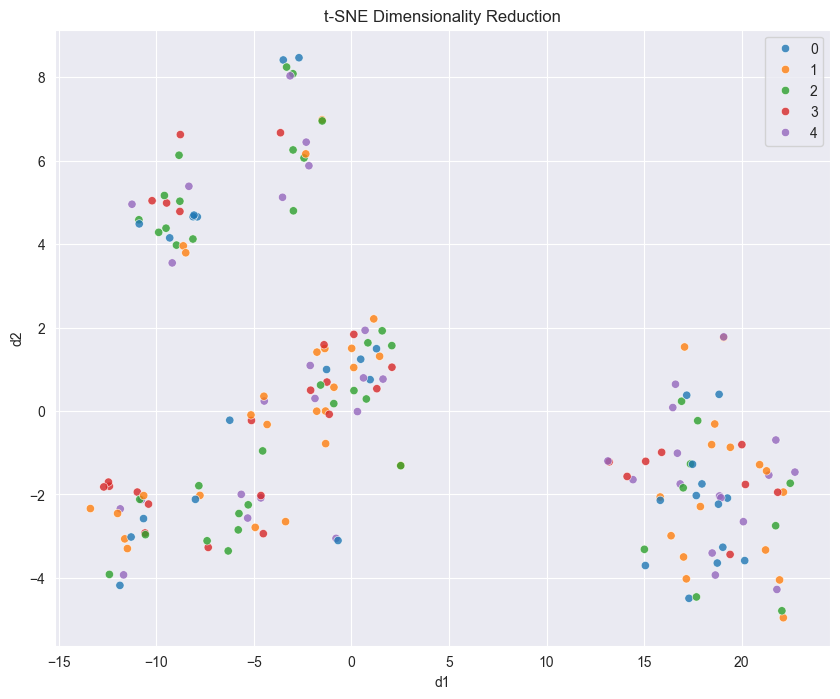

In [71]:
# Plotting samples in 2d
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_embedded_fs[:,0],
    y=X_embedded_fs[:,1],
    hue=Y_encoded_fs[:180],
    palette="tab10",
    legend="full",
    alpha=0.8,
)
plt.title("t-SNE Dimensionality Reduction")
plt.xlabel("d1")
plt.ylabel("d2")
plt.show()